In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load Dataset

In [2]:
df=pd.read_csv(r'C:\Users\EB\Downloads\insurance.csv')

# 2 DATA CLEANING

In [3]:
#detect missing values
df.isna()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [4]:
# Count detect missing values
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# 3. Preprocess Categorical Data

In [10]:
# Use One-Hot Encoding to convert sex, smoking status, and region into numerical values.
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# 4. Define Features (X) and Target (y)

In [19]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 5. Train the Linear Regression Model

In [49]:
# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
#Acts as a "grade" for your model. 
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
#Gives the average error in simple dollars. 
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):.2f}")
#Acts as a "warning system" for big mistakes.
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

R² Score: 0.7836
Mean Absolute Error: $4181.19
Root Mean Squared Error (RMSE): $5796.28


# 6. Visualizations

Text(0.5, 1.0, 'Impact of Age on Insurance Charges')

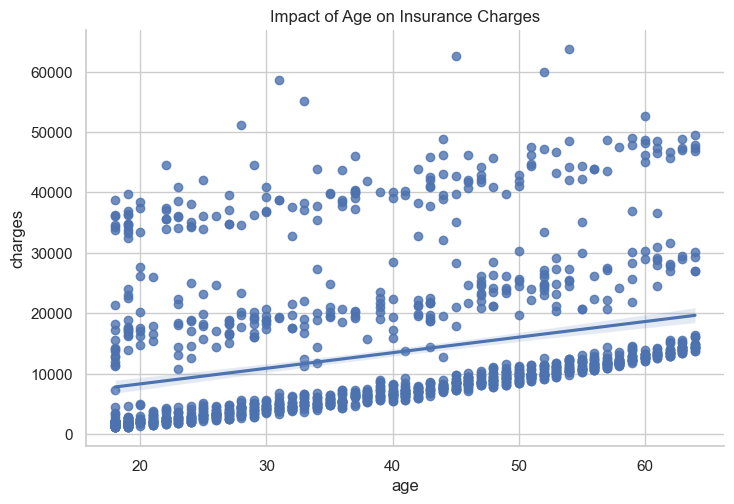

In [45]:
# 1. Age vs Charges
sns.lmplot(x='age', y='charges', data=df, aspect=1.5)
plt.title("Impact of Age on Insurance Charges")

Text(0.5, 1.0, 'Impact of BMI and Smoking on Charges')

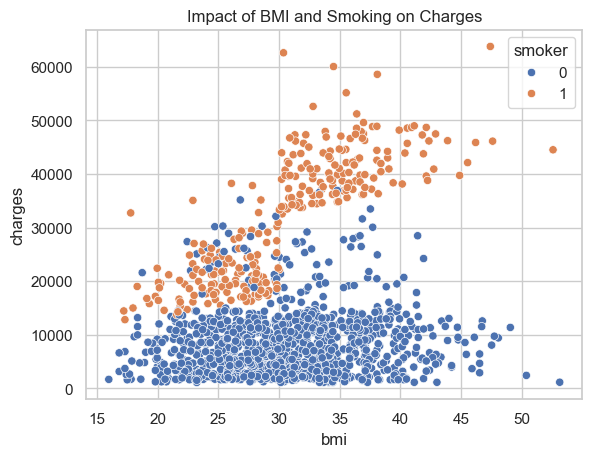

In [46]:
# BMI vs Charges (grouped by Smoker status)
#(0 for non smoker vs 1 for smoker)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("Impact of BMI and Smoking on Charges")

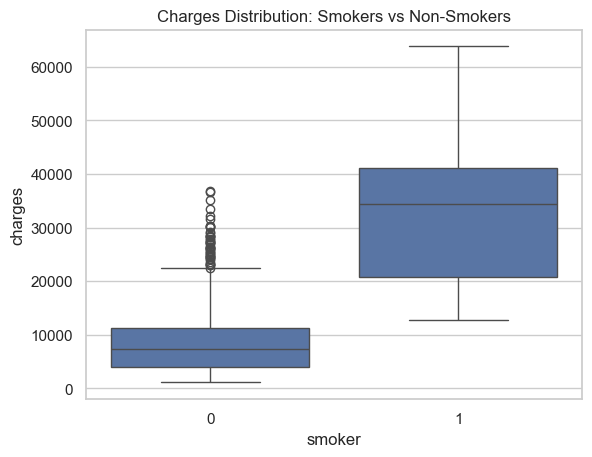

In [47]:
# 3. Smoking Status Boxplot
#(0 for non smoker vs 1 for smoker)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges Distribution: Smokers vs Non-Smokers")

plt.show()